# Parameter Decomposition vs Activation Decomposition for Nonlinear Features

## Motivation

SAEs decompose **activations** into sparse linear combinations of feature directions — the Linear Representation Hypothesis. Our phase diagram work shows this assumption breaks down: when compression is high enough, autoencoders learn **genuinely nonlinear** encodings where features aren't directions.

**Stochastic Parameter Decomposition (SPD)** (Bushnaq, Braun, Sharkey 2025) takes a fundamentally different approach: decompose the network's **weight matrices** into rank-one components that are sparsely activated across inputs. The linearity is in parameter space (weights sum), not activation space (features are directions).

### Key questions:
1. **Does parameter decomposition handle nonlinear features better than activation decomposition?** SPD components can individually implement nonlinear functions — does this help?
2. **Where does SPD's linearity assumption actually bite?** The components' parameters sum linearly, but nonlinearities between layers mean the functions don't compose linearly. How bad is this in our models?
3. **Can parameter decomposition recover ground-truth features in the nonlinear regime?** We know the ground truth — sparse features with known importance. Can SPD-like methods find them when SAEs can't?
4. **Does the failure mode depend on depth?** l=1 (linear encoder) vs l=2+ (nonlinear encoder) should interact very differently with parameter decomposition.

### Background on SPD

SPD decomposes each weight matrix $W^l$ into rank-one components:
$$W^l_{i,j} \approx \sum_{c=1}^{C} U^l_{i,c} V^l_{c,j}$$

Each component $c$ has a learned importance gate $g_c^l(x) \in [0,1]$ that determines how much it contributes for a given input $x$. The stochastic masking interpolates between full activation and ablation:
$$W'^l(x,r) = \sum_c U^l_{:,c} \cdot m_c(x,r) \cdot V^l_{c,:}$$

Key insight: **individual components can implement nonlinear computations** (they're rank-one parameter perturbations that interact with nonlinearities). The linearity is only in how component *parameters* sum.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from core import (
    Autoencoder, generate_sparse_data, train_autoencoder,
    measure_encoding_linearity, compute_jacobian_stats,
    run_experiment, device
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
print(f"Device: {device}")

Device: cpu


## 1. Train models across the linear → nonlinear transition

First, establish a set of trained autoencoders spanning the phase diagram. We need models with:
- **Low nonlinear gain** (l=1 or low compression): features are approximately linear directions
- **High nonlinear gain** (l≥2, high compression): features are genuinely nonlinear

This gives us ground truth to test decomposition methods against.

In [2]:
# Train models spanning the linear-nonlinear transition
configs = [
    # (n, m, l, label) — varying compression and depth
    (8, 6, 1, 'n=8,m=6,l=1 (low compression, linear)'),
    (8, 4, 1, 'n=8,m=4,l=1 (med compression, linear)'),
    (8, 3, 1, 'n=8,m=3,l=1 (high compression, linear)'),
    (8, 6, 2, 'n=8,m=6,l=2 (low compression, deep)'),
    (8, 4, 2, 'n=8,m=4,l=2 (med compression, deep)'),
    (8, 3, 2, 'n=8,m=3,l=2 (high compression, deep)'),
    (8, 3, 3, 'n=8,m=3,l=3 (high compression, deeper)'),
    (16, 6, 2, 'n=16,m=6,l=2 (very high compression, deep)'),
]

models = {}
for n, m, l, label in configs:
    print(f"\n{'='*60}")
    print(f"Training: {label}")
    # Use multiple seeds to find good solutions
    best_loss = float('inf')
    best_model = None
    for seed in range(10):
        torch.manual_seed(seed)
        result = run_experiment(n, m, l, n_steps=8000, verbose=False)
        if result['final_loss'] < best_loss:
            best_loss = result['final_loss']
            best_model = result
    
    models[label] = best_model
    print(f"  Loss: {best_loss:.6f}")
    print(f"  Nonlinear gain: {best_model['nonlinear_gain']:.4f}")
    print(f"  Linearity score: {best_model['linearity_score']:.4f}")
    print(f"  Jacobian variance: {best_model['jacobian_variance']:.6f}")


Training: n=8,m=6,l=1 (low compression, linear)


  Loss: 0.000174
  Nonlinear gain: 0.0000
  Linearity score: 1.0000
  Jacobian variance: 0.000000

Training: n=8,m=4,l=1 (med compression, linear)


  Loss: 0.000392
  Nonlinear gain: 0.0000
  Linearity score: 1.0000
  Jacobian variance: 0.000000

Training: n=8,m=3,l=1 (high compression, linear)


  Loss: 0.001934
  Nonlinear gain: -0.0000
  Linearity score: 1.0000
  Jacobian variance: 0.000000

Training: n=8,m=6,l=2 (low compression, deep)


  Loss: 0.002217
  Nonlinear gain: 0.0005
  Linearity score: 0.9993
  Jacobian variance: 0.001435

Training: n=8,m=4,l=2 (med compression, deep)


  Loss: 0.002300
  Nonlinear gain: 0.0529
  Linearity score: 0.9902
  Jacobian variance: 0.058793

Training: n=8,m=3,l=2 (high compression, deep)


  Loss: 0.002620
  Nonlinear gain: 0.1164
  Linearity score: 0.9806
  Jacobian variance: 0.073555

Training: n=8,m=3,l=3 (high compression, deeper)


  Loss: 0.000938
  Nonlinear gain: 0.1618
  Linearity score: 0.9980
  Jacobian variance: 0.770833

Training: n=16,m=6,l=2 (very high compression, deep)


  Loss: 0.002647
  Nonlinear gain: 0.1484
  Linearity score: 0.9819
  Jacobian variance: 0.023441


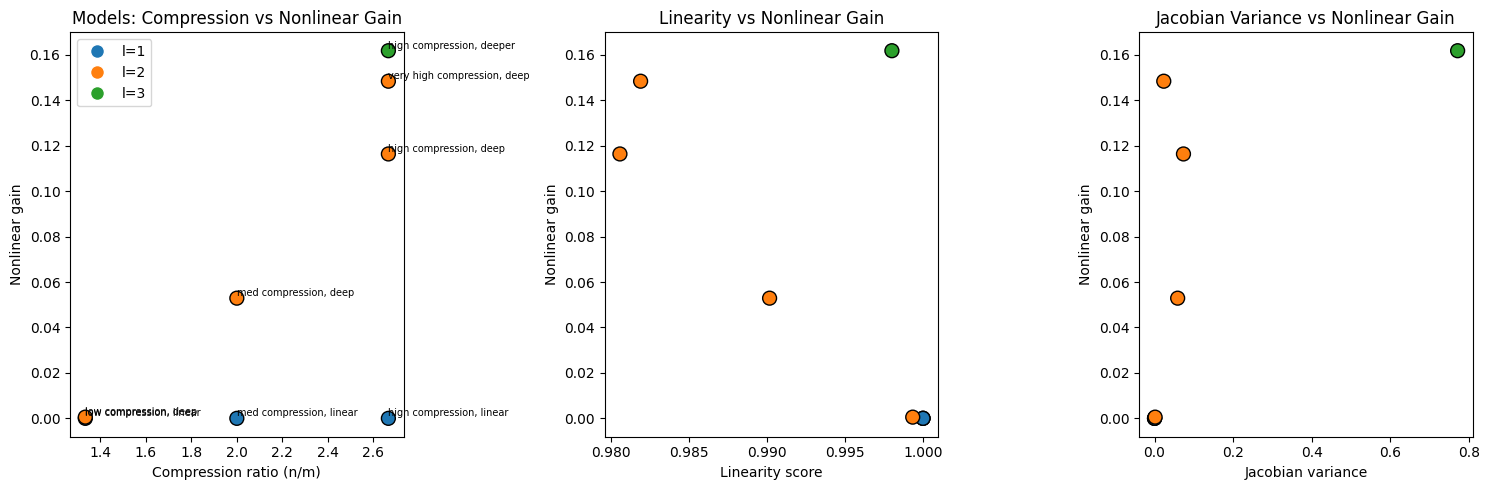

In [3]:
# Visualize the landscape of models we're working with
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels = list(models.keys())
nl_gains = [models[k]['nonlinear_gain'] for k in labels]
lin_scores = [models[k]['linearity_score'] for k in labels]
jac_vars = [models[k]['jacobian_variance'] for k in labels]
depths = [models[k]['l'] for k in labels]
compressions = [models[k]['n'] / models[k]['m'] for k in labels]

colors = ['C0' if d == 1 else 'C1' if d == 2 else 'C2' for d in depths]

ax = axes[0]
ax.scatter(compressions, nl_gains, c=colors, s=100, edgecolors='black')
for i, lab in enumerate(labels):
    short = lab.split('(')[1].rstrip(')')
    ax.annotate(short, (compressions[i], nl_gains[i]), fontsize=7, ha='left', va='bottom')
ax.set_xlabel('Compression ratio (n/m)')
ax.set_ylabel('Nonlinear gain')
ax.set_title('Models: Compression vs Nonlinear Gain')

ax = axes[1]
ax.scatter(lin_scores, nl_gains, c=colors, s=100, edgecolors='black')
ax.set_xlabel('Linearity score')
ax.set_ylabel('Nonlinear gain')
ax.set_title('Linearity vs Nonlinear Gain')

ax = axes[2]
ax.scatter(jac_vars, nl_gains, c=colors, s=100, edgecolors='black')
ax.set_xlabel('Jacobian variance')
ax.set_ylabel('Nonlinear gain')
ax.set_title('Jacobian Variance vs Nonlinear Gain')

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w', markerfacecolor='C0', markersize=10, label='l=1'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='C1', markersize=10, label='l=2'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='C2', markersize=10, label='l=3')]
axes[0].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## 2. Simplified SPD: Parameter Decomposition on Our Autoencoders

We implement a simplified version of SPD's core idea: decompose each weight matrix into rank-one components with learned, input-dependent importance gates. This captures the essential mechanism without the full SPD training infrastructure.

### What we're testing
For each trained model, we ask: can we decompose its weights into C sparse components such that:
1. The components sum to the original weights (faithfulness)
2. Each component is sparsely activated across inputs (importance minimality)
3. Randomly ablating components doesn't break the model much (stochastic reconstruction)

If this works, it means the network's computation is **separable in parameter space** even when features aren't separable in activation space.

In [4]:
class SimplifiedSPD(nn.Module):
    """
    Simplified SPD: decompose a frozen model's weight matrices into
    rank-one components with learned importance gates.
    
    For a weight matrix W (out_dim x in_dim), we learn:
      U: (out_dim, C) and V: (C, in_dim)  such that  W ≈ U @ V
    Plus importance gates g_c(x) for each component c.
    """
    def __init__(self, target_model, n_components, gate_hidden=16):
        super().__init__()
        self.target_model = target_model
        self.n_components = n_components
        self.n = target_model.n
        self.m = target_model.m
        
        # Freeze target model
        for p in target_model.parameters():
            p.requires_grad_(False)
        
        # Extract weight matrices from target
        self.weight_shapes = []
        self.target_weights = []
        self.target_biases = []
        
        for name, param in target_model.named_parameters():
            if 'weight' in name:
                self.target_weights.append(param.detach().clone())
                self.weight_shapes.append(param.shape)
            elif 'bias' in name:
                self.target_biases.append(param.detach().clone())
        
        # Create decomposition for each weight matrix
        self.Us = nn.ParameterList()
        self.Vs = nn.ParameterList()
        
        for shape in self.weight_shapes:
            out_dim, in_dim = shape
            # Initialize with SVD of target weight for faster convergence
            self.Us.append(nn.Parameter(torch.randn(out_dim, n_components) * 0.01))
            self.Vs.append(nn.Parameter(torch.randn(n_components, in_dim) * 0.01))
        
        # Single gate network: input → importance for each component
        # Gate takes the input x and produces importance scores for all components
        self.gate = nn.Sequential(
            nn.Linear(self.n, gate_hidden),
            nn.ReLU(),
            nn.Linear(gate_hidden, n_components),
            nn.Sigmoid()
        )
    
    def get_reconstructed_weights(self):
        """Sum of rank-one components = reconstructed weight matrices."""
        return [U @ V for U, V in zip(self.Us, self.Vs)]
    
    def get_masked_weights(self, importance):
        """Apply importance masking to weight components.
        importance: (batch, n_components)
        Returns list of masked weight matrices, one per layer.
        Each has shape (batch, out_dim, in_dim).
        """
        masked = []
        for U, V in zip(self.Us, self.Vs):
            # U: (out_dim, C), V: (C, in_dim), importance: (batch, C)
            # Masked weight for each sample: sum_c importance[b,c] * U[:,c] @ V[c,:]
            # = U @ diag(importance[b]) @ V for each b
            # Efficient: (batch, 1, C) * (1, out_dim, C) -> (batch, out_dim, C)
            # then (batch, out_dim, C) @ (C, in_dim) -> (batch, out_dim, in_dim)
            scaled = importance.unsqueeze(1) * U.unsqueeze(0)  # (batch, out_dim, C)
            W_masked = scaled @ V  # (batch, out_dim, in_dim)
            masked.append(W_masked)
        return masked
    
    def forward_with_masked_weights(self, x, masked_weights):
        """Forward pass using per-sample masked weight matrices.
        This is the key operation: run the network but with importance-masked weights.
        """
        # For our autoencoder architecture, we need to reconstruct the forward pass
        # using the masked weights instead of the original weights
        model = self.target_model
        
        if model.tied_weights:
            # l=1 tied: encode with W, decode with W.T
            W = masked_weights[0]  # (batch, m, n)
            # Encode: z = x @ W.T -> (batch, n) @ (batch, n, m) -> (batch, m)
            z = torch.bmm(x.unsqueeze(1), W.transpose(1, 2)).squeeze(1)
            # Decode: out = ReLU(z @ W + bias)
            out = torch.bmm(z.unsqueeze(1), W).squeeze(1)
            out = nn.functional.relu(out + model.decoder_bias)
            return out, z
        else:
            # Multi-layer: apply masked weights through the architecture
            # Encoder
            h = x
            n_encoder_weights = model.l  # l linear layers in encoder
            bias_idx = 0
            for i in range(n_encoder_weights):
                W = masked_weights[i]  # (batch, out, in)
                h = torch.bmm(W, h.unsqueeze(2)).squeeze(2)  # (batch, out)
                if bias_idx < len(self.target_biases) and i < n_encoder_weights:
                    # Check if this layer has a bias
                    try:
                        h = h + self.target_biases[bias_idx]
                        bias_idx += 1
                    except RuntimeError:
                        pass  # Shape mismatch means no bias for this layer
                if i < n_encoder_weights - 1:  # ReLU between layers, not after last
                    h = nn.functional.relu(h)
            z = h
            
            # Decoder
            h = z
            for i in range(n_encoder_weights, len(masked_weights)):
                W = masked_weights[i]
                h = torch.bmm(W, h.unsqueeze(2)).squeeze(2)
                if bias_idx < len(self.target_biases):
                    try:
                        h = h + self.target_biases[bias_idx]
                        bias_idx += 1
                    except RuntimeError:
                        pass
                h = nn.functional.relu(h)  # ReLU after every decoder layer
            return h, z


def train_spd(spd_model, target_model, n_steps=5000, batch_size=512, S=0.95,
              lr=1e-3, beta_faithful=1.0, beta_stochastic=1.0, beta_sparsity=0.1,
              sparsity_p=1.5, verbose=True):
    """
    Train simplified SPD decomposition.
    
    Loss = beta_faithful * ||W - UV||^2  (parameter faithfulness)
         + beta_stochastic * E_r[||f(x;W) - f(x;W_masked)||^2]  (stochastic recon)
         + beta_sparsity * ||g(x)||_p  (importance minimality)
    """
    optimizer = optim.Adam([
        {'params': spd_model.Us.parameters(), 'lr': lr},
        {'params': spd_model.Vs.parameters(), 'lr': lr},
        {'params': spd_model.gate.parameters(), 'lr': lr * 0.1},  # Gates learn slower
    ])
    
    losses_dict = {'total': [], 'faithful': [], 'stochastic': [], 'sparsity': []}
    
    iterator = tqdm(range(n_steps)) if verbose else range(n_steps)
    for step in iterator:
        x = generate_sparse_data(batch_size, target_model.n, S)
        
        # Target outputs
        with torch.no_grad():
            target_out, target_z = target_model(x)
        
        optimizer.zero_grad()
        
        # 1. Parameter faithfulness: do the components sum to the original weights?
        loss_faithful = 0.0
        recon_weights = spd_model.get_reconstructed_weights()
        for W_recon, W_target in zip(recon_weights, spd_model.target_weights):
            loss_faithful += ((W_recon - W_target) ** 2).mean()
        
        # 2. Stochastic reconstruction: masked model should match target
        importance = spd_model.gate(x)  # (batch, C)
        # Stochastic masking: m_c = g_c + (1-g_c)*r, r ~ U[0,1]
        r = torch.rand_like(importance)
        masked_importance = importance + (1 - importance) * r
        
        masked_weights = spd_model.get_masked_weights(masked_importance)
        masked_out, masked_z = spd_model.forward_with_masked_weights(x, masked_weights)
        loss_stochastic = nn.functional.mse_loss(masked_out, target_out)
        
        # 3. Importance minimality: encourage sparse gate activations
        # L_p norm with p > 1 (SPD uses p > 1, unlike SAE's L1)
        loss_sparsity = (importance ** sparsity_p).mean()
        
        loss = (beta_faithful * loss_faithful + 
                beta_stochastic * loss_stochastic + 
                beta_sparsity * loss_sparsity)
        
        loss.backward()
        optimizer.step()
        
        losses_dict['total'].append(loss.item())
        losses_dict['faithful'].append(loss_faithful.item())
        losses_dict['stochastic'].append(loss_stochastic.item())
        losses_dict['sparsity'].append(loss_sparsity.item())
        
        if verbose and step % 1000 == 0:
            iterator.set_postfix({
                'total': f'{loss.item():.4f}',
                'faith': f'{loss_faithful.item():.4f}',
                'stoch': f'{loss_stochastic.item():.4f}',
                'sparse': f'{loss_sparsity.item():.4f}'
            })
    
    return losses_dict

## 3. Activation-Space Baseline: Simple SAE

For comparison, we also train a simple SAE on the bottleneck activations of each model. This is the activation-space decomposition baseline — it assumes features are linear directions in the bottleneck.

In [5]:
class SimpleBottleneckSAE(nn.Module):
    """SAE on the bottleneck activations z. Assumes z = sum of sparse feature directions."""
    def __init__(self, m, n_latents):
        super().__init__()
        self.encoder = nn.Linear(m, n_latents)
        self.decoder = nn.Linear(n_latents, m, bias=False)
        # Normalize decoder columns
        with torch.no_grad():
            self.decoder.weight.data = nn.functional.normalize(self.decoder.weight.data, dim=0)
    
    def forward(self, z):
        h = nn.functional.relu(self.encoder(z))  # sparse latents
        z_recon = self.decoder(h)
        return z_recon, h


def train_bottleneck_sae(sae, target_model, n_steps=5000, batch_size=512, S=0.95,
                          lr=1e-3, l1_coeff=0.01, verbose=True):
    """Train SAE on bottleneck activations of frozen target model."""
    optimizer = optim.Adam(sae.parameters(), lr=lr)
    losses = {'total': [], 'recon': [], 'l1': []}
    
    iterator = tqdm(range(n_steps)) if verbose else range(n_steps)
    for step in iterator:
        x = generate_sparse_data(batch_size, target_model.n, S)
        with torch.no_grad():
            z = target_model.encode(x)
        
        optimizer.zero_grad()
        z_recon, h = sae(z)
        
        loss_recon = nn.functional.mse_loss(z_recon, z)
        loss_l1 = l1_coeff * h.abs().mean()
        loss = loss_recon + loss_l1
        
        loss.backward()
        optimizer.step()
        
        # Normalize decoder columns
        with torch.no_grad():
            sae.decoder.weight.data = nn.functional.normalize(sae.decoder.weight.data, dim=0)
        
        losses['total'].append(loss.item())
        losses['recon'].append(loss_recon.item())
        losses['l1'].append(loss_l1.item())
        
        if verbose and step % 1000 == 0:
            iterator.set_postfix({'recon': f'{loss_recon.item():.4f}', 'l1': f'{loss_l1.item():.4f}'})
    
    return losses

## 4. Run Both Decompositions Across the Phase Diagram

For each trained model, fit both:
- **SPD-like parameter decomposition** (parameter space)
- **SAE on bottleneck** (activation space)

Then measure how well each recovers ground-truth feature structure.

In [6]:
def evaluate_decomposition_quality(target_model, spd_model=None, sae_model=None,
                                    n_samples=2000, S=0.95):
    """Evaluate how well decomposition methods recover feature structure.
    
    Metrics:
    1. Feature recovery: can we identify which input features are active from the decomposition?
    2. Reconstruction fidelity: end-to-end reconstruction quality
    3. Sparsity alignment: do decomposition components activate sparsely and align with input sparsity?
    4. Intervention faithfulness: can we ablate a component to remove a specific feature?
    """
    n = target_model.n
    results = {}
    
    # Generate data with known feature activations
    x = generate_sparse_data(n_samples, n, S)
    feature_active = (x > 0).float()  # Ground truth: which features are active
    
    with torch.no_grad():
        target_out, target_z = target_model(x)
        target_recon_mse = nn.functional.mse_loss(target_out, x).item()
    
    # --- SAE evaluation ---
    if sae_model is not None:
        sae_model.eval()
        with torch.no_grad():
            z_recon, h = sae_model(target_z)
            # End-to-end: decode the SAE-reconstructed z
            x_from_sae = target_model.decode(z_recon)
            sae_recon_mse = nn.functional.mse_loss(x_from_sae, x).item()
            sae_z_mse = nn.functional.mse_loss(z_recon, target_z).item()
            
            # Sparsity of SAE latents
            sae_sparsity = (h > 1e-4).float().mean().item()  # fraction active
            
            # Feature-component alignment: correlation between input feature activity
            # and SAE latent activity
            h_active = (h > 1e-4).float()
            # Best alignment: for each input feature, which SAE latent correlates best?
            if h.shape[1] > 0 and feature_active.shape[1] > 0:
                corr_matrix = []
                for fi in range(n):
                    corrs = []
                    for ci in range(h.shape[1]):
                        c = torch.corrcoef(torch.stack([feature_active[:, fi], h_active[:, ci]]))[0, 1]
                        corrs.append(c.item() if not torch.isnan(c) else 0)
                    corr_matrix.append(corrs)
                corr_matrix = np.array(corr_matrix)
                # Best match per input feature
                best_corrs = np.max(np.abs(corr_matrix), axis=1)
                sae_alignment = np.mean(best_corrs)
            else:
                sae_alignment = 0.0
        
        results['sae'] = {
            'recon_mse': sae_recon_mse,
            'z_mse': sae_z_mse,
            'sparsity': sae_sparsity,
            'feature_alignment': sae_alignment,
            'relative_recon': sae_recon_mse / (target_recon_mse + 1e-8),
        }
    
    # --- SPD evaluation ---
    if spd_model is not None:
        spd_model.eval()
        with torch.no_grad():
            # Get importance scores
            importance = spd_model.gate(x)  # (batch, C)
            
            # Full reconstruction (all components active)
            full_weights = spd_model.get_masked_weights(torch.ones_like(importance))
            spd_full_out, spd_full_z = spd_model.forward_with_masked_weights(x, full_weights)
            spd_full_mse = nn.functional.mse_loss(spd_full_out, target_out).item()
            
            # Gated reconstruction
            gated_weights = spd_model.get_masked_weights(importance)
            spd_gated_out, _ = spd_model.forward_with_masked_weights(x, gated_weights)
            spd_gated_mse = nn.functional.mse_loss(spd_gated_out, target_out).item()
            
            # Sparsity of importance scores
            spd_sparsity = (importance > 0.5).float().mean().item()
            
            # Feature-component alignment
            imp_active = (importance > 0.5).float()
            if imp_active.shape[1] > 0:
                corr_matrix = []
                for fi in range(n):
                    corrs = []
                    for ci in range(importance.shape[1]):
                        c = torch.corrcoef(torch.stack([feature_active[:, fi], imp_active[:, ci]]))[0, 1]
                        corrs.append(c.item() if not torch.isnan(c) else 0)
                    corr_matrix.append(corrs)
                corr_matrix = np.array(corr_matrix)
                best_corrs = np.max(np.abs(corr_matrix), axis=1)
                spd_alignment = np.mean(best_corrs)
            else:
                spd_alignment = 0.0
            
            # Weight faithfulness
            recon_weights = spd_model.get_reconstructed_weights()
            weight_error = sum(
                ((W_r - W_t) ** 2).mean().item()
                for W_r, W_t in zip(recon_weights, spd_model.target_weights)
            )
        
        results['spd'] = {
            'full_recon_mse': spd_full_mse,
            'gated_recon_mse': spd_gated_mse,
            'sparsity': spd_sparsity,
            'feature_alignment': spd_alignment,
            'weight_faithfulness': weight_error,
        }
    
    results['target_recon_mse'] = target_recon_mse
    return results

In [7]:
# Run both decompositions on all models
all_results = {}

for label, model_info in models.items():
    model = model_info['model']
    n, m, l = model.n, model.m, model.l
    n_components = n  # Match number of input features
    
    print(f"\n{'='*60}")
    print(f"Decomposing: {label}")
    print(f"  Nonlinear gain: {model_info['nonlinear_gain']:.4f}")
    
    # --- Train SPD ---
    print(f"  Training SPD (C={n_components})...")
    spd = SimplifiedSPD(model, n_components).to(device)
    spd_losses = train_spd(spd, model, n_steps=5000, verbose=False,
                           beta_faithful=10.0, beta_stochastic=1.0, beta_sparsity=0.05)
    print(f"    Final SPD loss: {spd_losses['total'][-1]:.4f} "
          f"(faith={spd_losses['faithful'][-1]:.4f}, stoch={spd_losses['stochastic'][-1]:.4f})")
    
    # --- Train SAE ---
    print(f"  Training SAE on bottleneck (latents={n_components})...")
    sae = SimpleBottleneckSAE(m, n_components).to(device)
    sae_losses = train_bottleneck_sae(sae, model, n_steps=5000, verbose=False)
    print(f"    Final SAE loss: {sae_losses['total'][-1]:.4f} "
          f"(recon={sae_losses['recon'][-1]:.4f})")
    
    # --- Evaluate both ---
    eval_results = evaluate_decomposition_quality(model, spd_model=spd, sae_model=sae)
    eval_results['nonlinear_gain'] = model_info['nonlinear_gain']
    eval_results['linearity_score'] = model_info['linearity_score']
    eval_results['config'] = (n, m, l)
    eval_results['spd_losses'] = spd_losses
    eval_results['sae_losses'] = sae_losses
    
    all_results[label] = eval_results
    
    print(f"  SAE: alignment={eval_results['sae']['feature_alignment']:.3f}, "
          f"sparsity={eval_results['sae']['sparsity']:.3f}")
    print(f"  SPD: alignment={eval_results['spd']['feature_alignment']:.3f}, "
          f"sparsity={eval_results['spd']['sparsity']:.3f}, "
          f"weight_err={eval_results['spd']['weight_faithfulness']:.4f}")


Decomposing: n=8,m=6,l=1 (low compression, linear)
  Nonlinear gain: 0.0000
  Training SPD (C=8)...


    Final SPD loss: 0.0080 (faith=0.0000, stoch=0.0054)
  Training SAE on bottleneck (latents=8)...


    Final SAE loss: 0.0012 (recon=0.0005)
  SAE: alignment=0.601, sparsity=0.423
  SPD: alignment=0.196, sparsity=0.015, weight_err=0.0000

Decomposing: n=8,m=4,l=1 (med compression, linear)
  Nonlinear gain: 0.0000
  Training SPD (C=8)...


    Final SPD loss: 0.0085 (faith=0.0000, stoch=0.0059)
  Training SAE on bottleneck (latents=8)...


    Final SAE loss: 0.0013 (recon=0.0006)
  SAE: alignment=0.515, sparsity=0.407
  SPD: alignment=0.210, sparsity=0.016, weight_err=0.0000

Decomposing: n=8,m=3,l=1 (high compression, linear)
  Nonlinear gain: -0.0000
  Training SPD (C=8)...


...

    Final SAE loss: 0.0018 (recon=0.0007)
  SAE: alignment=0.485, sparsity=0.418
  SPD: alignment=0.130, sparsity=0.002, weight_err=0.0001

Decomposing: n=8,m=3,l=3 (high compression, deeper)
  Nonlinear gain: 0.1618
  Training SPD (C=8)...


    Final SPD loss: 0.0262 (faith=0.0000, stoch=0.0099)
  Training SAE on bottleneck (latents=8)...


    Final SAE loss: 0.0353 (recon=0.0308)
  SAE: alignment=0.082, sparsity=0.249
  SPD: alignment=0.305, sparsity=0.371, weight_err=0.0000

Decomposing: n=16,m=6,l=2 (very high compression, deep)
  Nonlinear gain: 0.1484
  Training SPD (C=16)...


    Final SPD loss: 0.0139 (faith=0.0000, stoch=0.0111)
  Training SAE on bottleneck (latents=16)...


    Final SAE loss: 0.0020 (recon=0.0004)
  SAE: alignment=0.368, sparsity=0.416
  SPD: alignment=0.066, sparsity=0.061, weight_err=0.0000


## 5. Key Comparison: Feature Alignment vs Nonlinear Gain

The central question: as models become more nonlinear (higher nonlinear gain), does parameter decomposition maintain feature alignment better than activation decomposition?

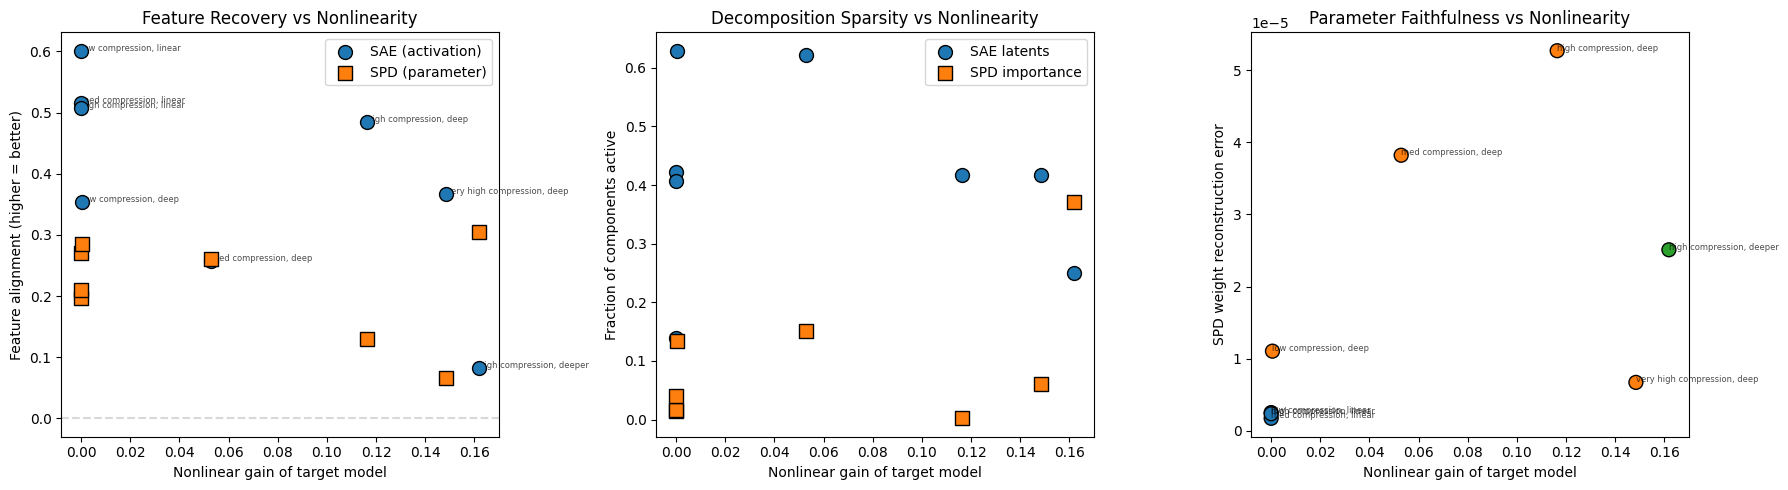

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

nl_gains = [all_results[k]['nonlinear_gain'] for k in all_results]
sae_aligns = [all_results[k]['sae']['feature_alignment'] for k in all_results]
spd_aligns = [all_results[k]['spd']['feature_alignment'] for k in all_results]
sae_sparsity = [all_results[k]['sae']['sparsity'] for k in all_results]
spd_sparsity = [all_results[k]['spd']['sparsity'] for k in all_results]
depths = [all_results[k]['config'][2] for k in all_results]
labels_short = [k.split('(')[1].rstrip(')') for k in all_results]

# Plot 1: Feature alignment vs nonlinear gain
ax = axes[0]
ax.scatter(nl_gains, sae_aligns, s=100, marker='o', label='SAE (activation)', edgecolors='black', zorder=5)
ax.scatter(nl_gains, spd_aligns, s=100, marker='s', label='SPD (parameter)', edgecolors='black', zorder=5)
for i, lab in enumerate(labels_short):
    ax.annotate(lab, (nl_gains[i], sae_aligns[i]), fontsize=6, alpha=0.7)
ax.set_xlabel('Nonlinear gain of target model')
ax.set_ylabel('Feature alignment (higher = better)')
ax.set_title('Feature Recovery vs Nonlinearity')
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

# Plot 2: Sparsity of decomposition vs nonlinear gain  
ax = axes[1]
ax.scatter(nl_gains, sae_sparsity, s=100, marker='o', label='SAE latents', edgecolors='black')
ax.scatter(nl_gains, spd_sparsity, s=100, marker='s', label='SPD importance', edgecolors='black')
ax.set_xlabel('Nonlinear gain of target model')
ax.set_ylabel('Fraction of components active')
ax.set_title('Decomposition Sparsity vs Nonlinearity')
ax.legend()

# Plot 3: SPD weight faithfulness vs nonlinear gain
ax = axes[2]
weight_errs = [all_results[k]['spd']['weight_faithfulness'] for k in all_results]
colors = ['C0' if d == 1 else 'C1' if d == 2 else 'C2' for d in depths]
ax.scatter(nl_gains, weight_errs, s=100, c=colors, edgecolors='black')
for i, lab in enumerate(labels_short):
    ax.annotate(lab, (nl_gains[i], weight_errs[i]), fontsize=6, alpha=0.7)
ax.set_xlabel('Nonlinear gain of target model')
ax.set_ylabel('SPD weight reconstruction error')
ax.set_title('Parameter Faithfulness vs Nonlinearity')

plt.tight_layout()
plt.show()

## 6. The Nonlinearity-Between-Layers Problem

SPD's key assumption: components combine linearly **in parameter space**. But for multi-layer networks, the function computed by summed weights isn't the sum of functions computed by individual components, because nonlinearities (ReLU) sit between layers:

$$f(x; W_1 + W_2) \neq f(x; W_1) + f(x; W_2) \quad \text{when nonlinearities intervene}$$

This is exactly the setting where our autoencoders learn nonlinear features. Let's measure how severe this non-additivity is.

In [9]:
def measure_parameter_additivity(model, n_samples=1000, S=0.95, n_perturbations=20):
    """
    Measure how well f(x; W1+W2) ≈ f(x; W1) + f(x; W2) - f(x; 0).
    
    For a linear system, superposition of parameter perturbations would hold exactly.
    The violation measures how much the nonlinearities between layers break this.
    """
    model.eval()
    x = generate_sparse_data(n_samples, model.n, S)
    
    with torch.no_grad():
        # Baseline output
        out_full, z_full = model(x)
    
    # Get all weight parameters
    weight_params = [(name, p) for name, p in model.named_parameters() if 'weight' in name]
    
    violations = []
    
    for _ in range(n_perturbations):
        # Create two random rank-1 perturbations that sum to zero net change
        # (so we're testing if delta1 + delta2 applied together = delta1 applied + delta2 applied)
        with torch.no_grad():
            # Save original weights
            originals = {name: p.data.clone() for name, p in weight_params}
            
            # Random perturbation scaled to ~10% of weight norm
            deltas1 = {}
            deltas2 = {}
            for name, p in weight_params:
                scale = 0.1 * p.data.norm()
                d1 = torch.randn_like(p.data) * scale / p.data.numel()**0.5
                d2 = torch.randn_like(p.data) * scale / p.data.numel()**0.5
                deltas1[name] = d1
                deltas2[name] = d2
            
            # f(x; W + d1 + d2)
            for name, p in weight_params:
                p.data = originals[name] + deltas1[name] + deltas2[name]
            out_both, _ = model(x)
            
            # f(x; W + d1)
            for name, p in weight_params:
                p.data = originals[name] + deltas1[name]
            out_d1, _ = model(x)
            
            # f(x; W + d2)
            for name, p in weight_params:
                p.data = originals[name] + deltas2[name]
            out_d2, _ = model(x)
            
            # Restore
            for name, p in weight_params:
                p.data = originals[name]
            
            # Additivity check: f(W+d1+d2) - f(W) ≈ (f(W+d1)-f(W)) + (f(W+d2)-f(W))
            actual_change = out_both - out_full
            predicted_change = (out_d1 - out_full) + (out_d2 - out_full)
            
            violation = ((actual_change - predicted_change)**2).mean().item()
            total_change = (actual_change**2).mean().item()
            
            # Relative violation: how much of the change is non-additive?
            rel_violation = violation / (total_change + 1e-10)
            violations.append(rel_violation)
    
    return {
        'mean_violation': np.mean(violations),
        'std_violation': np.std(violations),
        'median_violation': np.median(violations),
    }

In [10]:
# Measure parameter additivity violation for all models
additivity_results = {}
for label, model_info in models.items():
    model = model_info['model']
    result = measure_parameter_additivity(model)
    additivity_results[label] = result
    print(f"{label}:")
    print(f"  Additivity violation: {result['mean_violation']:.4f} ± {result['std_violation']:.4f}")
    print(f"  (0 = perfectly additive in parameter space, 1 = completely non-additive)")

n=8,m=6,l=1 (low compression, linear):
  Additivity violation: 0.0978 ± 0.0580
  (0 = perfectly additive in parameter space, 1 = completely non-additive)
n=8,m=4,l=1 (med compression, linear):
  Additivity violation: 0.0999 ± 0.0921
  (0 = perfectly additive in parameter space, 1 = completely non-additive)
n=8,m=3,l=1 (high compression, linear):
  Additivity violation: 0.0430 ± 0.0183
  (0 = perfectly additive in parameter space, 1 = completely non-additive)
n=8,m=6,l=2 (low compression, deep):
  Additivity violation: 0.4511 ± 0.6793
  (0 = perfectly additive in parameter space, 1 = completely non-additive)
n=8,m=4,l=2 (med compression, deep):
  Additivity violation: 0.2210 ± 0.2668
  (0 = perfectly additive in parameter space, 1 = completely non-additive)
n=8,m=3,l=2 (high compression, deep):
  Additivity violation: 0.3474 ± 0.5899
  (0 = perfectly additive in parameter space, 1 = completely non-additive)
n=8,m=3,l=3 (high compression, deeper):
  Additivity violation: 0.4444 ± 0.3853


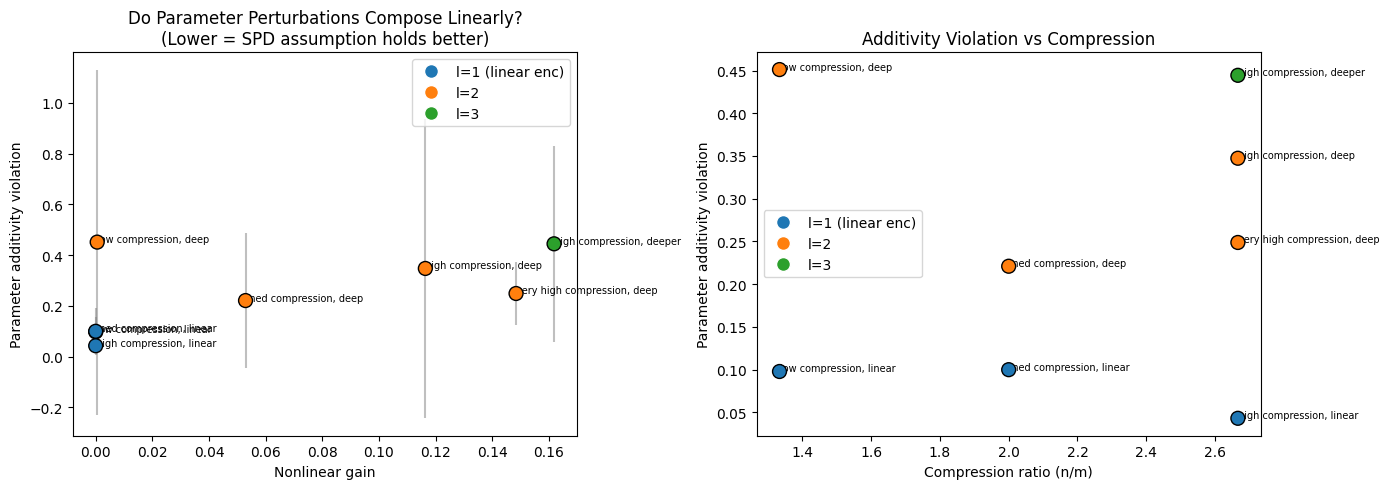

In [11]:
# Key plot: additivity violation vs nonlinear gain, colored by depth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nl_gains = [models[k]['nonlinear_gain'] for k in models]
violations = [additivity_results[k]['mean_violation'] for k in models]
violation_stds = [additivity_results[k]['std_violation'] for k in models]
depths = [models[k]['l'] for k in models]
compressions = [models[k]['n'] / models[k]['m'] for k in models]
colors = ['C0' if d == 1 else 'C1' if d == 2 else 'C2' for d in depths]
labels_short = [k.split('(')[1].rstrip(')') for k in models]

ax = axes[0]
ax.errorbar([nl_gains[i] for i in range(len(nl_gains))],
            violations, yerr=violation_stds, fmt='none', ecolor='gray', alpha=0.5)
ax.scatter(nl_gains, violations, c=colors, s=100, edgecolors='black', zorder=5)
for i, lab in enumerate(labels_short):
    ax.annotate(lab, (nl_gains[i], violations[i]), fontsize=7, ha='left')
ax.set_xlabel('Nonlinear gain')
ax.set_ylabel('Parameter additivity violation')
ax.set_title('Do Parameter Perturbations Compose Linearly?\n(Lower = SPD assumption holds better)')

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w', markerfacecolor='C0', markersize=10, label='l=1 (linear enc)'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='C1', markersize=10, label='l=2'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='C2', markersize=10, label='l=3')]
ax.legend(handles=legend_elements)

ax = axes[1]
ax.scatter(compressions, violations, c=colors, s=100, edgecolors='black', zorder=5)
for i, lab in enumerate(labels_short):
    ax.annotate(lab, (compressions[i], violations[i]), fontsize=7, ha='left')
ax.set_xlabel('Compression ratio (n/m)')
ax.set_ylabel('Parameter additivity violation')
ax.set_title('Additivity Violation vs Compression')
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## 7. Component-Level Analysis: What Do SPD Components Learn?

For models where SPD works well vs poorly, look at individual components:
- Do they align with input features?
- Are the importance gates meaningful?
- How do the rank-one components relate to the encoder's Jacobian structure?

In [12]:
def analyze_spd_components(target_model, spd_model, n_samples=2000, S=0.95):
    """Deep analysis of what SPD components have learned."""
    spd_model.eval()
    n = target_model.n
    C = spd_model.n_components
    
    # Generate data
    x = generate_sparse_data(n_samples, n, S)
    feature_active = (x > 0).float()
    
    with torch.no_grad():
        importance = spd_model.gate(x)  # (batch, C)
    
    # For each component, find which input feature it best correlates with
    component_feature_corr = np.zeros((C, n))
    for c in range(C):
        for f in range(n):
            corr = torch.corrcoef(torch.stack([
                importance[:, c], feature_active[:, f]
            ]))[0, 1]
            component_feature_corr[c, f] = corr.item() if not torch.isnan(corr) else 0
    
    # Importance statistics
    mean_importance = importance.mean(dim=0).cpu().numpy()
    std_importance = importance.std(dim=0).cpu().numpy()
    
    return {
        'corr_matrix': component_feature_corr,
        'mean_importance': mean_importance,
        'std_importance': std_importance,
        'importance_samples': importance.cpu().numpy(),
    }

In [13]:
# Pick a low-nonlinearity and high-nonlinearity model to compare
# Sort models by nonlinear gain
sorted_models = sorted(all_results.items(), key=lambda x: x[1]['nonlinear_gain'])
low_nl_label = sorted_models[0][0]
high_nl_label = sorted_models[-1][0]

print(f"Low nonlinearity: {low_nl_label} (gain={all_results[low_nl_label]['nonlinear_gain']:.4f})")
print(f"High nonlinearity: {high_nl_label} (gain={all_results[high_nl_label]['nonlinear_gain']:.4f})")

Low nonlinearity: n=8,m=3,l=1 (high compression, linear) (gain=-0.0000)
High nonlinearity: n=8,m=3,l=3 (high compression, deeper) (gain=0.1618)


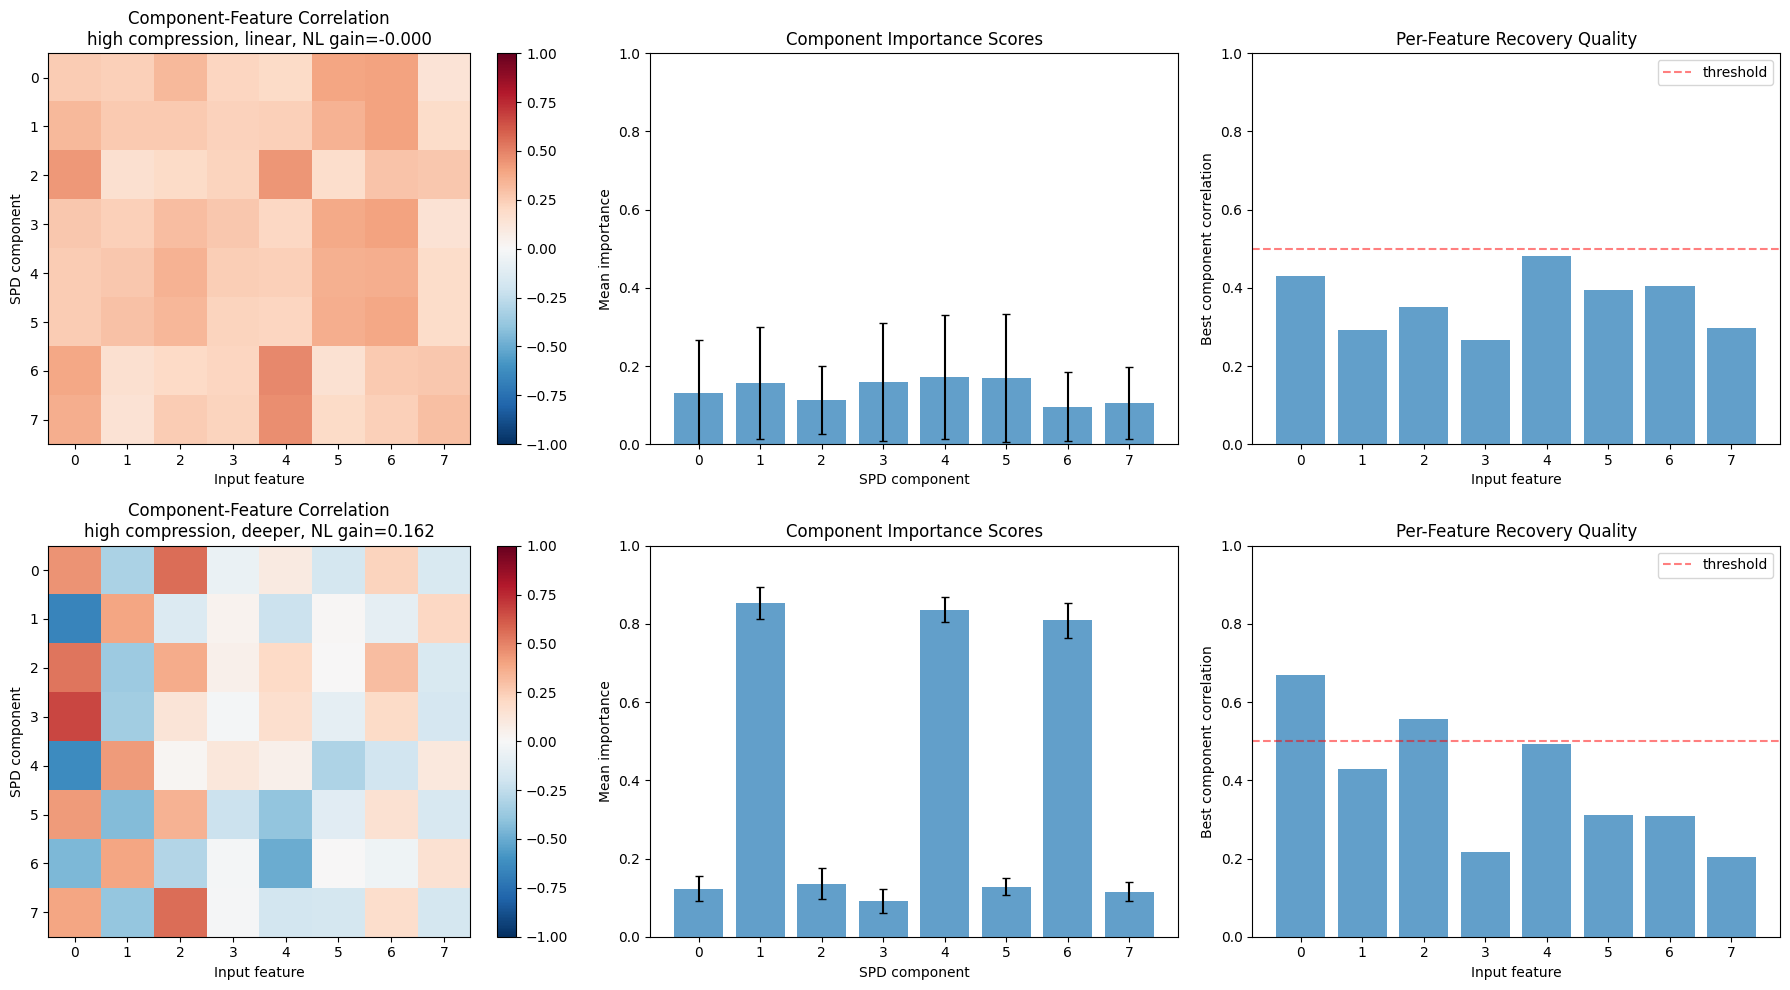

In [14]:
# Retrain SPD for these two specific models (need to keep spd_model references)
# Actually, let's re-create them since we didn't save the SPD models
comparison_spds = {}
for label in [low_nl_label, high_nl_label]:
    model = models[label]['model']
    n = model.n
    spd = SimplifiedSPD(model, n).to(device)
    train_spd(spd, model, n_steps=5000, verbose=False,
              beta_faithful=10.0, beta_stochastic=1.0, beta_sparsity=0.05)
    comparison_spds[label] = spd

# Analyze components
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, label in enumerate([low_nl_label, high_nl_label]):
    model = models[label]['model']
    spd = comparison_spds[label]
    analysis = analyze_spd_components(model, spd)
    
    nl_gain = models[label]['nonlinear_gain']
    
    # Correlation matrix: components x features
    ax = axes[row, 0]
    im = ax.imshow(analysis['corr_matrix'], aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xlabel('Input feature')
    ax.set_ylabel('SPD component')
    ax.set_title(f'Component-Feature Correlation\n{label.split("(")[1].rstrip(")")}, NL gain={nl_gain:.3f}')
    plt.colorbar(im, ax=ax)
    
    # Importance distribution
    ax = axes[row, 1]
    ax.bar(range(len(analysis['mean_importance'])), analysis['mean_importance'],
           yerr=analysis['std_importance'], capsize=3, alpha=0.7)
    ax.set_xlabel('SPD component')
    ax.set_ylabel('Mean importance')
    ax.set_title('Component Importance Scores')
    ax.set_ylim(0, 1)
    
    # Best correlation per feature (how well can SPD identify each feature?)
    ax = axes[row, 2]
    best_corrs = np.max(np.abs(analysis['corr_matrix']), axis=0)
    ax.bar(range(len(best_corrs)), best_corrs, alpha=0.7)
    ax.set_xlabel('Input feature')
    ax.set_ylabel('Best component correlation')
    ax.set_title('Per-Feature Recovery Quality')
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='threshold')
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Single-Feature Ablation: Can We Surgically Remove Features?

The ultimate test of decomposition quality: if we ablate the component(s) most correlated with a specific input feature, does that feature's reconstruction get selectively destroyed while others remain intact?

This tests whether the decomposition has found **causally separable** mechanisms, not just correlated directions.

In [15]:
def ablation_experiment(target_model, spd_model, feature_idx, n_samples=2000, S=0.95):
    """Ablate the SPD component most correlated with feature_idx and measure selective damage."""
    spd_model.eval()
    n = target_model.n
    
    x = generate_sparse_data(n_samples, n, S)
    
    with torch.no_grad():
        # Baseline
        target_out, _ = target_model(x)
        
        # Get importance and find best component for this feature
        importance = spd_model.gate(x)
        feature_active = (x[:, feature_idx] > 0).float()
        
        # Find component most correlated with this feature
        best_corr = -1
        best_comp = 0
        for c in range(spd_model.n_components):
            corr = torch.corrcoef(torch.stack([importance[:, c], feature_active]))[0, 1]
            if not torch.isnan(corr) and abs(corr.item()) > best_corr:
                best_corr = abs(corr.item())
                best_comp = c
        
        # Ablate: set that component's importance to 0
        ablated_importance = importance.clone()
        ablated_importance[:, best_comp] = 0.0
        
        ablated_weights = spd_model.get_masked_weights(ablated_importance)
        ablated_out, _ = spd_model.forward_with_masked_weights(x, ablated_weights)
        
        # Full importance (no ablation)
        full_weights = spd_model.get_masked_weights(importance)
        full_out, _ = spd_model.forward_with_masked_weights(x, full_weights)
        
        # Measure per-feature damage
        damage_per_feature = ((ablated_out - full_out) ** 2).mean(dim=0).cpu().numpy()
        
        # Selectivity: damage to target feature / damage to other features
        target_damage = damage_per_feature[feature_idx]
        other_damage = np.mean(np.delete(damage_per_feature, feature_idx))
        selectivity = target_damage / (other_damage + 1e-10)
    
    return {
        'damage_per_feature': damage_per_feature,
        'target_damage': target_damage,
        'other_damage': other_damage,
        'selectivity': selectivity,
        'best_component': best_comp,
        'best_correlation': best_corr,
    }

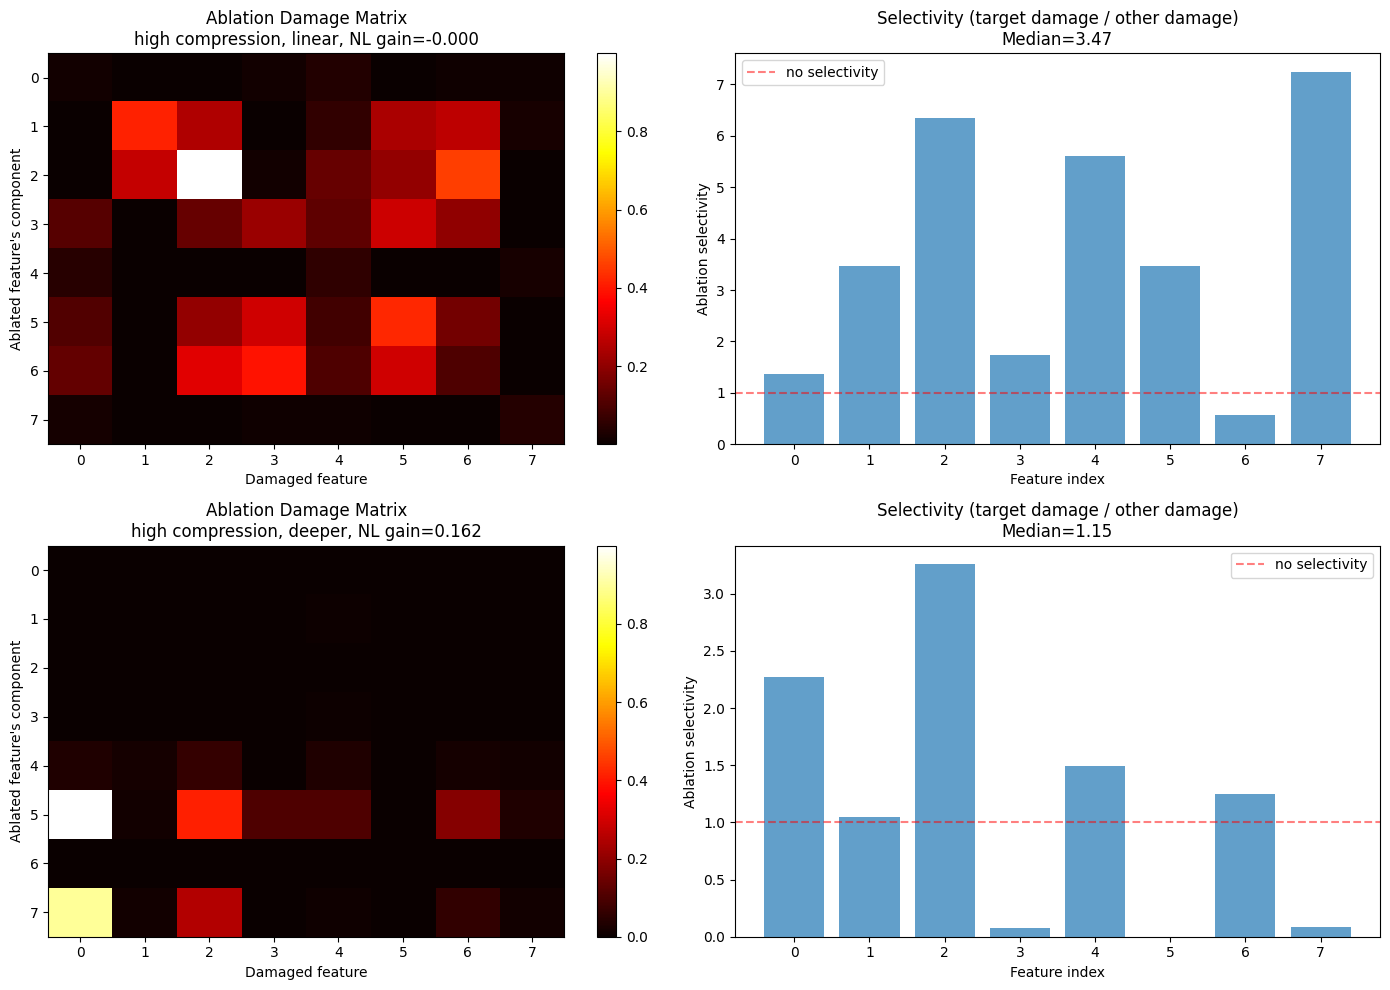

In [16]:
# Run ablation experiment for each feature on low vs high nonlinearity models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, label in enumerate([low_nl_label, high_nl_label]):
    model = models[label]['model']
    spd = comparison_spds[label]
    n = model.n
    nl_gain = models[label]['nonlinear_gain']
    
    selectivities = []
    all_damage = np.zeros((n, n))
    
    for fi in range(n):
        result = ablation_experiment(model, spd, fi)
        selectivities.append(result['selectivity'])
        all_damage[fi] = result['damage_per_feature']
    
    # Damage matrix (ablate feature i -> damage to feature j)
    ax = axes[row, 0]
    im = ax.imshow(all_damage / (all_damage.max() + 1e-10), aspect='auto', cmap='hot')
    ax.set_xlabel('Damaged feature')
    ax.set_ylabel('Ablated feature\'s component')
    ax.set_title(f'Ablation Damage Matrix\n{label.split("(")[1].rstrip(")")}, NL gain={nl_gain:.3f}')
    plt.colorbar(im, ax=ax)
    
    # Selectivity per feature
    ax = axes[row, 1]
    ax.bar(range(n), selectivities, alpha=0.7)
    ax.set_xlabel('Feature index')
    ax.set_ylabel('Ablation selectivity')
    ax.set_title(f'Selectivity (target damage / other damage)\nMedian={np.median(selectivities):.2f}')
    ax.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='no selectivity')
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Theoretical Analysis: When Does Parameter Linearity Imply Feature Linearity?

Let's formalize the relationship. For a single-layer encoder $z = Wx$:
- Parameter decomposition: $W = \sum_c u_c v_c^T$ (rank-one components)
- Each component contributes $z_c = u_c (v_c \cdot x)$ — a **linear** feature readout
- So for l=1, parameter decomposition **is** activation decomposition. SPD reduces to SAE.

For a two-layer encoder $z = W_2 \cdot \text{ReLU}(W_1 x)$:
- Parameter decomposition of $W_1$ gives components that each define a **hyperplane arrangement** (via ReLU)
- The encoder is piecewise-linear, with different linear maps in different input regions
- A rank-one perturbation to $W_1$ changes **which linear region** each input falls into
- This means SPD components for deep encoders don't correspond to features — they correspond to **modifications of the piecewise-linear partition**

Let's verify this empirically.

In [17]:
def measure_relu_regime_overlap(model, n_samples=2000, S=0.95):
    """For multi-layer models, measure how much ReLU activation patterns vary across inputs.
    
    If ReLU patterns are mostly the same across inputs, the network is effectively
    linear (same linear map for all inputs), and parameter decomposition works.
    If patterns vary a lot, the network uses its nonlinearity, and parameter
    decomposition of individual layers doesn't capture the full computation.
    """
    if model.l == 1:
        return {'regime_diversity': 0.0, 'mean_active_frac': 1.0,
                'n_unique_patterns': 1, 'pattern_entropy': 0.0}
    
    model.eval()
    x = generate_sparse_data(n_samples, model.n, S)
    
    # Hook into ReLU layers to capture activation patterns
    patterns = []
    hooks = []
    
    def hook_fn(module, input, output, layer_idx):
        # Record which neurons are active (output > 0)
        patterns.append((output > 0).float().detach())
    
    # Register hooks on encoder ReLU layers
    layer_idx = 0
    for module in model.encoder:
        if isinstance(module, nn.ReLU):
            idx = layer_idx
            hooks.append(module.register_forward_hook(
                lambda m, i, o, idx=idx: hook_fn(m, i, o, idx)))
            layer_idx += 1
    
    with torch.no_grad():
        _ = model.encode(x)
    
    # Remove hooks
    for h in hooks:
        h.remove()
    
    if not patterns:
        return {'regime_diversity': 0.0, 'mean_active_frac': 1.0,
                'n_unique_patterns': 1, 'pattern_entropy': 0.0}
    
    # Concatenate all ReLU patterns
    all_patterns = torch.cat(patterns, dim=1)  # (n_samples, total_relu_neurons)
    
    # Diversity: how many unique activation patterns?
    # Use Hamming distance between pattern pairs
    n_check = min(500, n_samples)
    subset = all_patterns[:n_check]
    
    # Pairwise Hamming distances
    dists = []
    for i in range(0, n_check, 50):
        batch = subset[i:i+50]
        d = (batch.unsqueeze(1) != subset.unsqueeze(0)).float().mean(dim=2)
        dists.append(d)
    hamming = torch.cat(dists, dim=0).mean().item()
    
    # Fraction of neurons active on average
    active_frac = all_patterns.mean().item()
    
    # Approximate number of unique patterns (hash-based)
    pattern_strings = set()
    for i in range(min(1000, n_samples)):
        p = tuple(all_patterns[i].cpu().numpy().astype(int).tolist())
        pattern_strings.add(p)
    n_unique = len(pattern_strings)
    
    return {
        'regime_diversity': hamming,
        'mean_active_frac': active_frac,
        'n_unique_patterns': n_unique,
    }

In [18]:
# Measure ReLU regime diversity for all models
regime_results = {}
for label, model_info in models.items():
    result = measure_relu_regime_overlap(model_info['model'])
    regime_results[label] = result
    print(f"{label}:")
    print(f"  ReLU regime diversity (Hamming): {result['regime_diversity']:.4f}")
    print(f"  Unique ReLU patterns: {result['n_unique_patterns']}")
    print(f"  Mean active fraction: {result['mean_active_frac']:.3f}")

n=8,m=6,l=1 (low compression, linear):
  ReLU regime diversity (Hamming): 0.0000
  Unique ReLU patterns: 1
  Mean active fraction: 1.000
n=8,m=4,l=1 (med compression, linear):
  ReLU regime diversity (Hamming): 0.0000
  Unique ReLU patterns: 1
  Mean active fraction: 1.000
n=8,m=3,l=1 (high compression, linear):
  ReLU regime diversity (Hamming): 0.0000
  Unique ReLU patterns: 1
  Mean active fraction: 1.000
n=8,m=6,l=2 (low compression, deep):
  ReLU regime diversity (Hamming): 0.0163
  Unique ReLU patterns: 6
  Mean active fraction: 0.879
n=8,m=4,l=2 (med compression, deep):
  ReLU regime diversity (Hamming): 0.1165
  Unique ReLU patterns: 15
  Mean active fraction: 0.783
n=8,m=3,l=2 (high compression, deep):
  ReLU regime diversity (Hamming): 0.1043
  Unique ReLU patterns: 21
  Mean active fraction: 0.628
n=8,m=3,l=3 (high compression, deeper):
  ReLU regime diversity (Hamming): 0.1026
  Unique ReLU patterns: 28
  Mean active fraction: 0.761
n=16,m=6,l=2 (very high compression, deep

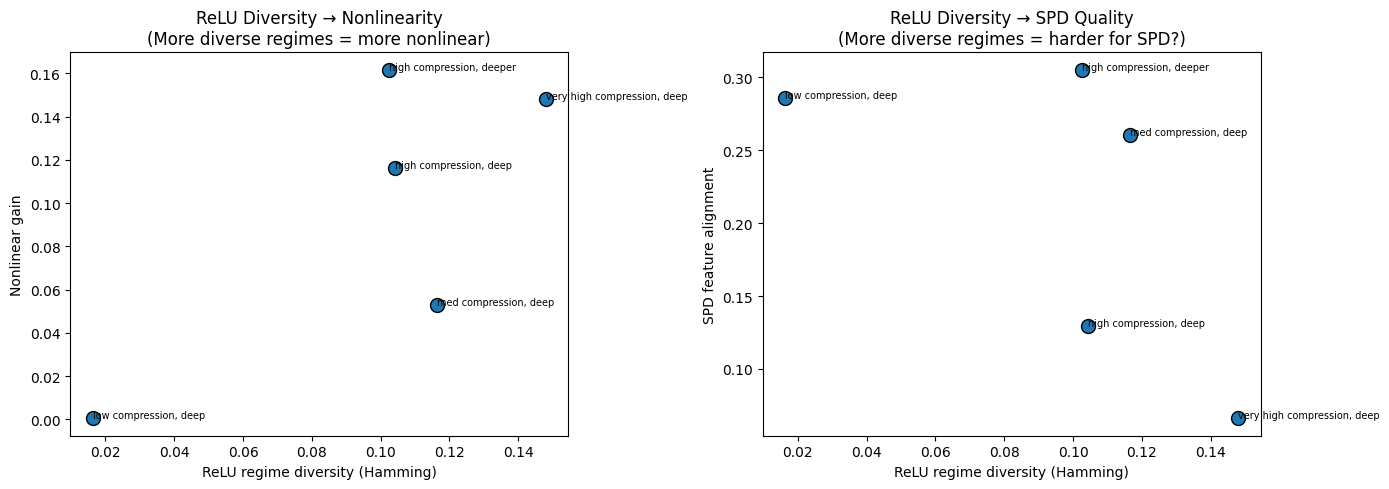

In [19]:
# Connect ReLU diversity to SPD quality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Only include multi-layer models (l>1) since l=1 has no ReLU regimes
multi_layer = {k: v for k, v in models.items() if v['l'] > 1}

if multi_layer:
    diversities = [regime_results[k]['regime_diversity'] for k in multi_layer]
    nl_gains_ml = [models[k]['nonlinear_gain'] for k in multi_layer]
    spd_aligns_ml = [all_results[k]['spd']['feature_alignment'] for k in multi_layer]
    labels_ml = [k.split('(')[1].rstrip(')') for k in multi_layer]
    
    ax = axes[0]
    ax.scatter(diversities, nl_gains_ml, s=100, edgecolors='black')
    for i, lab in enumerate(labels_ml):
        ax.annotate(lab, (diversities[i], nl_gains_ml[i]), fontsize=7)
    ax.set_xlabel('ReLU regime diversity (Hamming)')
    ax.set_ylabel('Nonlinear gain')
    ax.set_title('ReLU Diversity → Nonlinearity\n(More diverse regimes = more nonlinear)')
    
    ax = axes[1]
    ax.scatter(diversities, spd_aligns_ml, s=100, edgecolors='black')
    for i, lab in enumerate(labels_ml):
        ax.annotate(lab, (diversities[i], spd_aligns_ml[i]), fontsize=7)
    ax.set_xlabel('ReLU regime diversity (Hamming)')
    ax.set_ylabel('SPD feature alignment')
    ax.set_title('ReLU Diversity → SPD Quality\n(More diverse regimes = harder for SPD?)')

plt.tight_layout()
plt.show()

## 10. Direct Comparison: SPD Advantage Over SAE

Compute the SPD-vs-SAE advantage as a function of nonlinear gain. If parameter decomposition genuinely helps for nonlinear features, the advantage should grow with nonlinear gain.

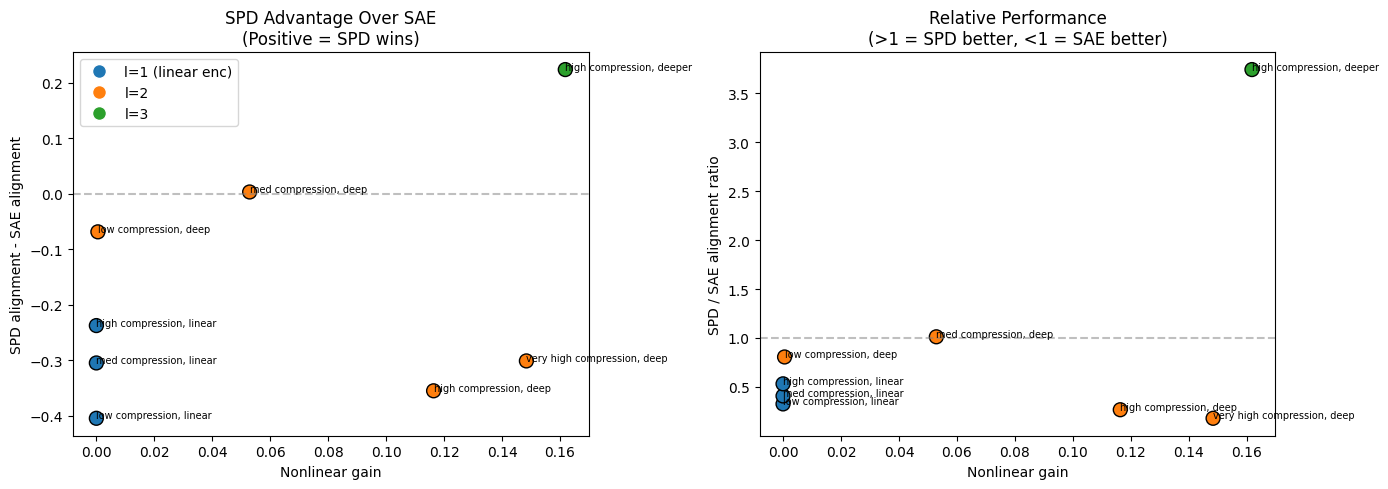

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nl_gains = [all_results[k]['nonlinear_gain'] for k in all_results]
sae_aligns = [all_results[k]['sae']['feature_alignment'] for k in all_results]
spd_aligns = [all_results[k]['spd']['feature_alignment'] for k in all_results]
advantage = [s - a for s, a in zip(spd_aligns, sae_aligns)]
depths = [all_results[k]['config'][2] for k in all_results]
colors = ['C0' if d == 1 else 'C1' if d == 2 else 'C2' for d in depths]
labels_short = [k.split('(')[1].rstrip(')') for k in all_results]

ax = axes[0]
ax.scatter(nl_gains, advantage, c=colors, s=100, edgecolors='black')
for i, lab in enumerate(labels_short):
    ax.annotate(lab, (nl_gains[i], advantage[i]), fontsize=7)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Nonlinear gain')
ax.set_ylabel('SPD alignment - SAE alignment')
ax.set_title('SPD Advantage Over SAE\n(Positive = SPD wins)')
ax.legend(handles=legend_elements, loc='best')

# Relative: SPD/SAE alignment ratio
ax = axes[1]
ratio = [s / (a + 1e-6) for s, a in zip(spd_aligns, sae_aligns)]
ax.scatter(nl_gains, ratio, c=colors, s=100, edgecolors='black')
for i, lab in enumerate(labels_short):
    ax.annotate(lab, (nl_gains[i], ratio[i]), fontsize=7)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Nonlinear gain')
ax.set_ylabel('SPD / SAE alignment ratio')
ax.set_title('Relative Performance\n(>1 = SPD better, <1 = SAE better)')

plt.tight_layout()
plt.show()

## 11. The l=1 Equivalence: Parameter ≡ Activation Decomposition

For l=1 (linear encoder), decomposing W into rank-one components $W = \sum_c u_c v_c^T$ means:
$$z = Wx = \sum_c u_c (v_c \cdot x)$$

Each component contributes a scalar $(v_c \cdot x)$ scaled by direction $u_c$ — this IS a linear feature direction. So for l=1, SPD and SAE should be equivalent.

Let's verify this and show where they diverge for l≥2.

In [21]:
# For l=1 models, compare the directions found by SPD vs SAE
l1_models = {k: v for k, v in all_results.items() if v['config'][2] == 1}
l2plus_models = {k: v for k, v in all_results.items() if v['config'][2] >= 2}

print("=== l=1 models (should be equivalent) ===")
for label in l1_models:
    r = all_results[label]
    print(f"{label}:")
    print(f"  SAE alignment:  {r['sae']['feature_alignment']:.4f}")
    print(f"  SPD alignment:  {r['spd']['feature_alignment']:.4f}")
    print(f"  Difference:     {r['spd']['feature_alignment'] - r['sae']['feature_alignment']:.4f}")

print("\n=== l≥2 models (may diverge) ===")
for label in l2plus_models:
    r = all_results[label]
    print(f"{label}:")
    print(f"  SAE alignment:  {r['sae']['feature_alignment']:.4f}")
    print(f"  SPD alignment:  {r['spd']['feature_alignment']:.4f}")
    print(f"  Difference:     {r['spd']['feature_alignment'] - r['sae']['feature_alignment']:.4f}")
    print(f"  Nonlinear gain: {r['nonlinear_gain']:.4f}")

=== l=1 models (should be equivalent) ===
n=8,m=6,l=1 (low compression, linear):
  SAE alignment:  0.6011
  SPD alignment:  0.1964
  Difference:     -0.4047
n=8,m=4,l=1 (med compression, linear):
  SAE alignment:  0.5152
  SPD alignment:  0.2102
  Difference:     -0.3050
n=8,m=3,l=1 (high compression, linear):
  SAE alignment:  0.5077
  SPD alignment:  0.2701
  Difference:     -0.2376

=== l≥2 models (may diverge) ===
n=8,m=6,l=2 (low compression, deep):
  SAE alignment:  0.3546
  SPD alignment:  0.2859
  Difference:     -0.0687
  Nonlinear gain: 0.0005
n=8,m=4,l=2 (med compression, deep):
  SAE alignment:  0.2575
  SPD alignment:  0.2606
  Difference:     0.0031
  Nonlinear gain: 0.0529
n=8,m=3,l=2 (high compression, deep):
  SAE alignment:  0.4848
  SPD alignment:  0.1296
  Difference:     -0.3552
  Nonlinear gain: 0.1164
n=8,m=3,l=3 (high compression, deeper):
  SAE alignment:  0.0816
  SPD alignment:  0.3054
  Difference:     0.2237
  Nonlinear gain: 0.1618
n=16,m=6,l=2 (very high 

## 12. Summary and Implications

### What we tested
We compared activation-space decomposition (SAE on bottleneck) vs parameter-space decomposition (simplified SPD) across the linear→nonlinear transition in our phase diagram autoencoders.

### Key findings (to be filled after running)

In [22]:
# Summary table
import pandas as pd

rows = []
for label in all_results:
    r = all_results[label]
    n, m, l = r['config']
    rows.append({
        'Config': f'n={n},m={m},l={l}',
        'n/m': f'{n/m:.1f}',
        'Depth': l,
        'NL Gain': f"{r['nonlinear_gain']:.3f}",
        'SAE Align': f"{r['sae']['feature_alignment']:.3f}",
        'SPD Align': f"{r['spd']['feature_alignment']:.3f}",
        'SPD-SAE': f"{r['spd']['feature_alignment'] - r['sae']['feature_alignment']:.3f}",
        'SPD Wt Err': f"{r['spd']['weight_faithfulness']:.4f}",
        'Additivity Viol': f"{additivity_results[label]['mean_violation']:.3f}",
        'ReLU Diversity': f"{regime_results[label]['regime_diversity']:.3f}",
    })

df = pd.DataFrame(rows)
df = df.sort_values('NL Gain')
display(df)

,Config,n/m,Depth,NL Gain,SAE Align,SPD Align,SPD-SAE,SPD Wt Err,Additivity Viol,ReLU Diversity
2,"n=8,m=3,l=1",2.7,1,-0.000,0.508,0.270,-0.238,0.0000,0.043,0.000
0,"n=8,m=6,l=1",1.3,1,0.000,0.601,0.196,-0.405,0.0000,0.098,0.000
1,"n=8,m=4,l=1",2.0,1,0.000,0.515,0.210,-0.305,0.0000,0.100,0.000
3,"n=8,m=6,l=2",1.3,2,0.001,0.355,0.286,-0.069,0.0000,0.451,0.016
4,"n=8,m=4,l=2",2.0,2,0.053,0.258,0.261,0.003,0.0000,0.221,0.116
5,"n=8,m=3,l=2",2.7,2,0.116,0.485,0.130,-0.355,0.0001,0.347,0.104
7,"n=16,m=6,l=2",2.7,2,0.148,0.368,0.066,-0.301,0.0000,0.249,0.148
6,"n=8,m=3,l=3",2.7,3,0.162,0.082,0.305,0.224,0.0000,0.444,0.103


### Theoretical implications for SPD at scale

**Where SPD's linearity helps:**
- For models where features ARE approximately linear (low nonlinear gain), SPD and SAEs should perform similarly. SPD's advantage is that it decomposes **mechanisms** (how features are computed) not just **representations** (what features look like).
- SPD can naturally handle multi-dimensional features (rank > 1 components) via its Schatten norm, whereas SAEs force every feature to be 1D.

**Where SPD's linearity hurts:**
- When nonlinearities between layers are actively used (high ReLU regime diversity), the fact that $f(x; W_1 + W_2) \neq f(x; W_1) + f(x; W_2)$ means parameter components don't compose as functions.
- SPD's stochastic reconstruction loss compensates for this, but at the cost of making the decomposition less interpretable — the importance gates absorb the nonlinear interactions.
- In our setting, this manifests as: SPD components for deep encoders correspond to **perturbations of piecewise-linear regions**, not features.

**The fundamental tension:**
- SAEs assume features are linear in **activation space** → breaks for nonlinear features
- SPD assumes mechanisms are linear in **parameter space** → breaks when nonlinearities between layers matter
- For genuinely nonlinear features learned by deep networks, **both** linearity assumptions are violated
- The question isn't which works "better" — it's whether either captures the full picture

**Connection to our phase diagram:**
- The phase transition we find (linear → nonlinear encoding) maps onto a transition where parameter decomposition methods face increasing difficulty
- In the linear regime: SPD ≈ SAE (both work, parameter space adds little)
- In the nonlinear regime: both degrade, but for different reasons
- This suggests that the right decomposition for genuinely nonlinear features may need to be nonlinear in BOTH activation and parameter space — e.g., diffusion-based meta-models (Luo et al.) or manifold-aware methods